In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, accuracy_score, confusion_matrix

In [12]:
# Create the RAW DATA
np.random.seed(42)
age = np.random.randint(18,70,150)
purchases = np.random.randint(5,100,150)

spend = (age*5)+(purchases*15)+np.random.normal(0,50,150)
premium_member = np.where((purchases>50)&(age<50),1,0)

df_store = pd.DataFrame({
    'Age': age,
    'Total_Purchases': purchases,
    'Yearly_Spend': spend,
    'Premium_Member': premium_member
})

X = df_store[['Age','Total_Purchases']]

print("--- RAW DATASET LOADED (First 10 rows) ---")
print(df_store.head(10),"\n")

--- RAW DATASET LOADED (First 10 rows) ---
   Age  Total_Purchases  Yearly_Spend  Premium_Member
0   56               13    483.741651               0
1   69               83   1529.157255               0
2   46               19    567.467370               0
3   32               94   1636.255283               1
4   60               46   1026.725053               0
5   25               81   1292.275137               1
6   38               55    977.441029               1
7   56               67   1228.478597               0
8   36               56   1058.498868               1
9   40                8    383.419476               0 



In [13]:
# Regression (Predicting Yearly Spend)
y_reg = df_store['Yearly_Spend']
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

model_reg = LinearRegression()
model_reg.fit(X_train_r, y_train_r)
predictions_reg = model_reg.predict(X_test_r)

print("--- REGRESSION METRICS ---")
print(f"MAE (Avg Dollar Error): ${mean_absolute_error(y_test_r, predictions_reg):,.2f}")
print(f"Base Price (Intercept): ${model_reg.intercept_:,.2f}\n")

--- REGRESSION METRICS ---
MAE (Avg Dollar Error): $38.05
Base Price (Intercept): $5.71



In [14]:
# Classification (Predicting Premium Membership)
y_clf = df_store['Premium_Member']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_clf, test_size=0.2, random_state=42)

model_clf = LogisticRegression()
model_clf.fit(X_train_c, y_train_c)
predictions_clf = model_clf.predict(X_test_c)

print("--- CLASSIFICATION METRICS ---")
print(f"Accuracy: {accuracy_score(y_test_c, predictions_clf)*100:.1f}%")
print("Confusion Matrix:")
print(pd.DataFrame(confusion_matrix(y_test_c, predictions_clf), 
                   columns=['Pred: No', 'Pred: Yes'], index=['Actual: No', 'Actual: Yes']), "\n")

--- CLASSIFICATION METRICS ---
Accuracy: 93.3%
Confusion Matrix:
             Pred: No  Pred: Yes
Actual: No         19          0
Actual: Yes         2          9 



In [15]:
# Clustering (Customer Segmentation)
model_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_store['Segment'] = model_kmeans.fit_predict(X)

print("--- CLUSTERING SUMMARY ---")
print(df_store.groupby('Segment')[['Age', 'Total_Purchases']].mean(), "\n")

--- CLUSTERING SUMMARY ---
               Age  Total_Purchases
Segment                            
0        41.302326        84.720930
1        42.526316        20.491228
2        44.100000        54.680000 



C:\Users\swarn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


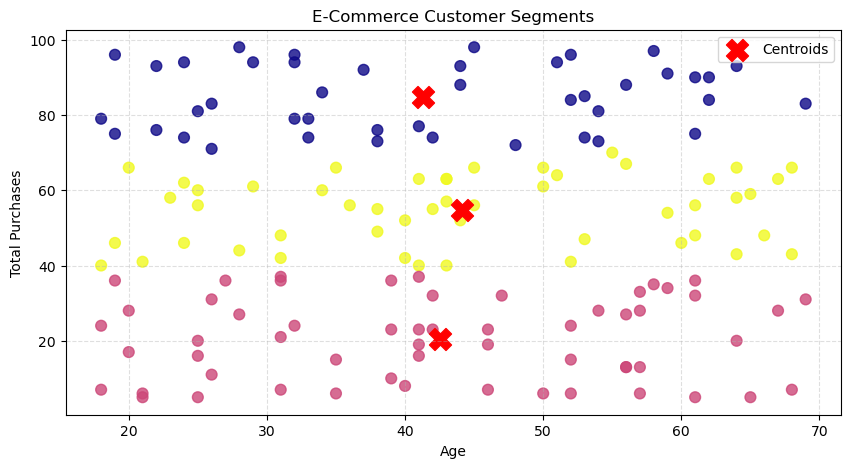

In [10]:
# VISUALIZE THE MASTERY
plt.figure(figsize=(10, 5))
plt.scatter(df_store['Age'], df_store['Total_Purchases'], c=df_store['Segment'], cmap='plasma', s=60, alpha=0.8)
centroids = model_kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=250, marker='X', label='Centroids')
plt.title("E-Commerce Customer Segments")
plt.xlabel("Age")
plt.ylabel("Total Purchases")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.show()